# Tarea 3 — Mapa de Calor de Pases Peligrosos

> Generar un mapa de calor con las zonas de pases mas peligrosas de un equipo, seleccionando competition_id y season_id desde el codigo libre de StatsBomb.

**Competicion:** La Liga 2015/2016 (`competition_id=11`, `season_id=27`)

**Equipo:** Real Madrid

**Nota:** Se eligio la temporada 2015/2016 porque es la unica temporada de La Liga en los datos abiertos de StatsBomb que incluye todos los partidos del Real Madrid (38 jornadas). Las temporadas mas recientes solo contienen los Clasicos.

In [1]:
# Importacion de librerias
# matplotlib.pyplot: libreria base para crear figuras, ejes y barras de color
# mplsoccer.Pitch: dibuja la cancha en orientacion horizontal
# mplsoccer.Sbopen: parser de datos StatsBomb integrado en mplsoccer
# pandas: manipulacion de datos tabulares; filtrado, concatenacion y aritmetica temporal
import matplotlib.pyplot as plt
from mplsoccer import Pitch, Sbopen
import pandas as pd

# Instanciamos el parser e importamos la lista de partidos de La Liga 2015/16
# competition_id=11 es La Liga; season_id=27 corresponde a la temporada 2015/2016
# Se eligio esta temporada porque contiene los 38 partidos del Real Madrid
parser = Sbopen()
df_match = parser.match(competition_id=11, season_id=27)

# Definimos el equipo a analizar
team = 'Real Madrid'

# Filtramos todos los partidos donde el Real Madrid fue local o visitante
# .to_list() convierte la Serie de match_id en una lista de Python para iterar
match_ids = df_match.loc[
    (df_match["home_team_name"] == team) | (df_match["away_team_name"] == team)
]["match_id"].to_list()
no_games = len(match_ids)
print(f"Partidos del Real Madrid en La Liga 2015/16: {no_games}")

Partidos del Real Madrid en La Liga 2015/16: 38


In [2]:
# Acumulamos "pases peligrosos" a lo largo de todos los partidos del Real Madrid.
# Un pase peligroso se define como cualquier pase completado por el Real Madrid
# que ocurrio dentro de una ventana de 15 segundos inmediatamente antes de
# uno de sus propios intentos de tiro.
# Esta heuristica identifica pases que contribuyeron directamente a secuencias
# ofensivas que terminaron en tiro — un proxy de participacion en la creacion de ocasiones.
danger_passes = pd.DataFrame()

for idx in match_ids:
    # parser.event() devuelve cuatro DataFrames; [0] es el flujo principal de eventos
    df = parser.event(idx)[0]

    # Procesamos cada mitad por separado para evitar que el descanso genere falsos positivos.
    # Un pase en el minuto 44 no deberia vincularse a un tiro en el minuto 46 (diferente periodo).
    for period in [1, 2]:

        # --- Recopilamos todos los pases completados del Real Madrid en este periodo ---
        # outcome_name.isnull() selecciona pases exitosos (los fallidos tienen outcome no nulo)
        mask_pass = (
            (df.team_name == team) &
            (df.type_name == "Pass") &
            (df.outcome_name.isnull()) &
            (df.period == period)
        )
        passes = df.loc[mask_pass, ["x", "y", "end_x", "end_y", "minute", "second", "player_name"]]

        # --- Recopilamos todos los tiros del Real Madrid en este periodo ---
        mask_shot = (
            (df.team_name == team) &
            (df.type_name == "Shot") &
            (df.period == period)
        )
        shots = df.loc[mask_shot, ["minute", "second"]]

        # Convertimos minuto+segundo a un valor absoluto en segundos para la aritmetica
        shot_times = shots["minute"] * 60 + shots["second"]

        # Definimos el inicio de la ventana de 15 segundos antes de cada tiro
        shot_window = 15
        shot_start = shot_times - shot_window
        shot_start = shot_start.apply(lambda i: i if i > 0 else (period - 1) * 45)

        pass_times = passes['minute'] * 60 + passes['second']

        # Para cada pase, verificamos si su timestamp cae dentro de alguna ventana de tiro
        pass_to_shot = pass_times.apply(
            lambda x: True in ((shot_start < x) & (x < shot_times)).unique()
        )

        danger_passes_period = passes.loc[pass_to_shot]
        danger_passes = pd.concat([danger_passes, danger_passes_period], ignore_index=True)

print(f"Total de pases peligrosos del Real Madrid en la temporada: {len(danger_passes)}")

Total de pases peligrosos del Real Madrid en la temporada: 2024


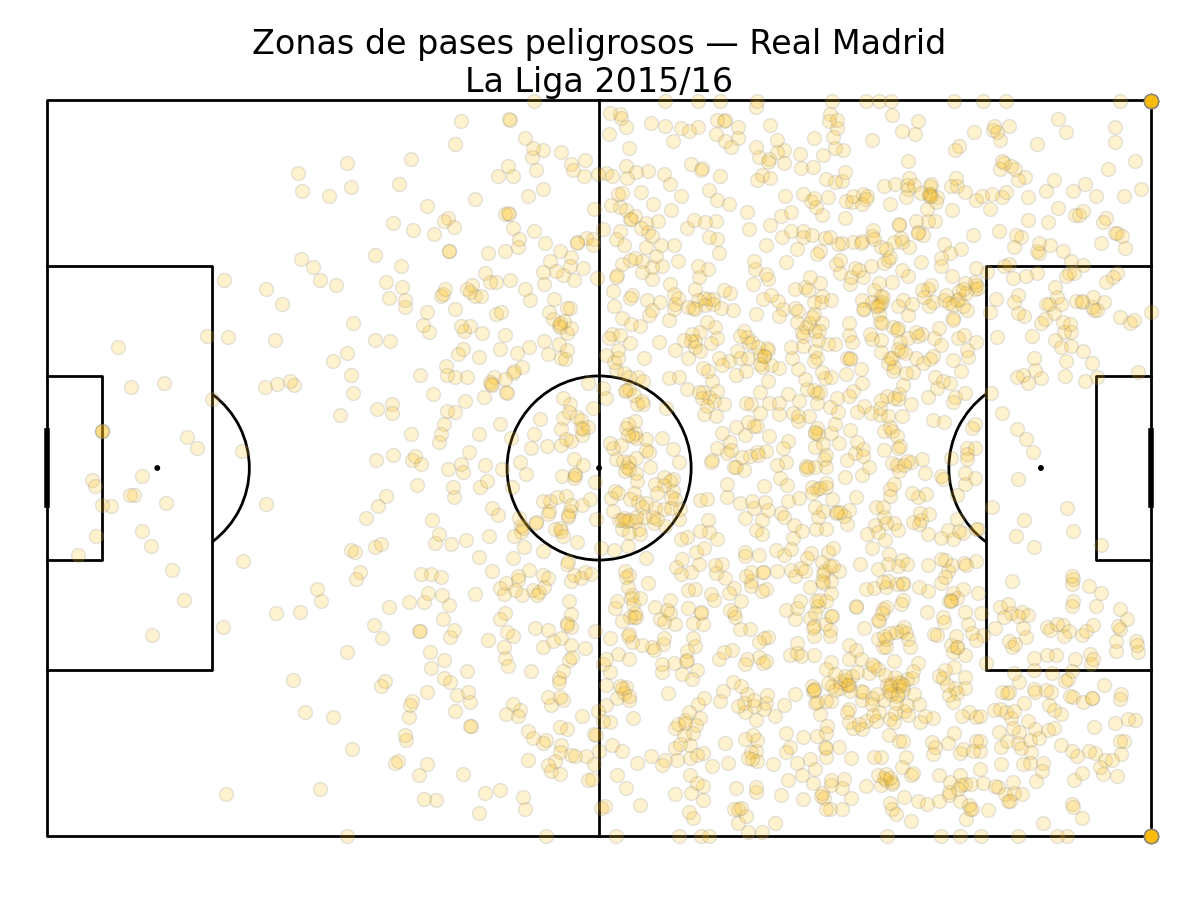

In [3]:
# --- Scatter plot: distribucion espacial de origenes de pases peligrosos ---
# Cada marcador representa un pase peligroso en coordenadas (x, y) a lo largo de la temporada.
# alpha=0.2 hace los marcadores semitransparentes para visualizar la densidad por superposicion.
pitch = Pitch(line_color='black')
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)
pitch.scatter(
    danger_passes.x, danger_passes.y,
    s=100, color='#FEBE10', edgecolors='grey', linewidth=1, alpha=0.2,
    ax=ax["pitch"]
)
fig.suptitle(f'Zonas de pases peligrosos — {team}\nLa Liga 2015/16', fontsize=24)
plt.show()

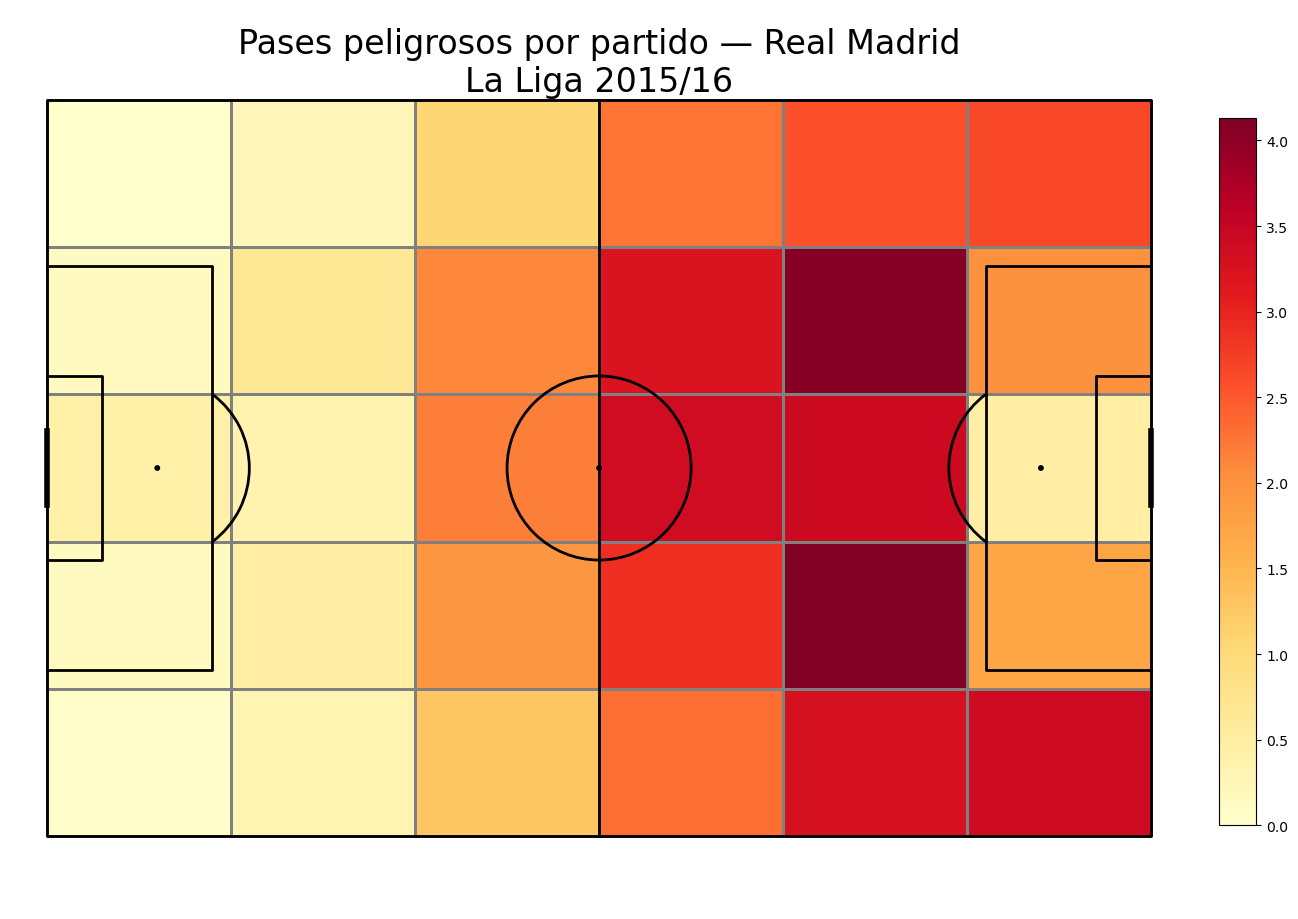

In [4]:
# --- Mapa de calor binneado: densidad de pases peligrosos normalizada por partido ---
# line_zorder=2 asegura que las lineas de la cancha se rendericen sobre el relleno del heatmap.
pitch = Pitch(line_color='black', line_zorder=2)
fig, ax = pitch.grid(
    grid_height=0.9, title_height=0.06, axis=False,
    endnote_height=0.04, title_space=0, endnote_space=0
)

# pitch.bin_statistic() divide la cancha en una cuadricula de celdas rectangulares
# y calcula una estadistica agregada dentro de cada celda.
# bins=(6, 5) crea una cuadricula de 6 columnas x 5 filas (30 zonas en total).
# statistic='count' cuenta el numero de origenes de pases peligrosos en cada celda.
bin_statistic = pitch.bin_statistic(
    danger_passes.x, danger_passes.y,
    statistic='count', bins=(6, 5), normalize=False
)

# Dividimos la matriz de conteos por no_games para convertir totales acumulados
# a promedio por partido. Esto normaliza la duracion del torneo.
bin_statistic["statistic"] = bin_statistic["statistic"] / no_games

# pitch.heatmap() renderiza la estadistica binneada como un mapa de colores sobre la cancha.
# cmap='YlOrRd' (amarillo-naranja-rojo) para representar los colores del Real Madrid.
# El pcm devuelto (PathCollection/mappable) se necesita para la barra de color.
pcm = pitch.heatmap(bin_statistic, cmap='YlOrRd', edgecolor='grey', ax=ax['pitch'])

# Agregamos una barra de color vertical para mostrar la escala de conteos
ax_cbar = fig.add_axes((1, 0.093, 0.03, 0.786))
cbar = plt.colorbar(pcm, cax=ax_cbar)

fig.suptitle(f'Pases peligrosos por partido — {team}\nLa Liga 2015/16', fontsize=24)
plt.show()

## Analisis del mapa de calor

El mapa de calor de pases peligrosos del Real Madrid en La Liga 2015/16 (temporada completa, 38 partidos) revela patrones claros sobre como el equipo de Zidane/Benitez construyo sus oportunidades de gol:

1. **Dominio por ambas bandas:** A diferencia de equipos que priorizan un costado, el Real Madrid muestra alta actividad en ambas bandas ofensivas. Esto refleja la presencia de Cristiano Ronaldo por la izquierda y Bale/Lucas Vazquez por la derecha, generando peligro desde multiples angulos.

2. **Zona central del ultimo tercio como foco principal:** La mayor densidad de pases peligrosos se concentra en la franja central entre la linea de mediocampo y el area rival. Los mediocampistas como Kroos, Modric e Isco eran los encargados de conectar el juego con los atacantes.

3. **Actividad alta en las zonas de centros laterales:** Se observa densidad significativa en las zonas de banda cerca del area rival, indicando que el Real Madrid recurria frecuentemente a centros laterales como recurso ofensivo — coherente con el perfil aereo de Cristiano Ronaldo y Benzema.

4. **Poca actividad desde la mitad propia:** Las zonas defensivas tienen valores muy bajos, lo que indica que los pases que precedieron a los tiros se originaban desde posiciones avanzadas. El Real Madrid de esa temporada era un equipo vertical que buscaba llegar rapidamente al tercio final.

**Conclusion:** El Real Madrid de la temporada 2015/16 genero sus oportunidades de manera equilibrada por ambas bandas y la zona central, con un estilo mas directo y vertical que el Barcelona del temario. La distribucion amplia de pases peligrosos refleja un equipo con multiples vias de ataque y no dependiente de un solo costado.